In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance

from pygam import LinearGAM, s
from functools import reduce
import operator

from xgboost import XGBRegressor

# For ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import shap

# ---------- Configuration ----------
RANDOM_STATE = 42
TEST_SIZE = 0.2          # last 20% of time as final test set
CV_FOLDS = 5

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ======================================================
# 1) Load data and prepare spatio-temporal information
# ======================================================
df = pd.read_csv("/Users/arup/Documents/ug_thesis/data_normalized.csv")
# expected columns:
# ['time', 'latitude', 'longitude',
#  'uo', 'vo', 'kd', 'fe', 'no3', 'po4', 'si', 'o2', 'ph', 'so',
#  'spco2', 'thetao', 'wo', 'chl']

FEATURES = ['uo', 'vo', 'kd', 'fe', 'no3', 'po4', 'si', 'o2', 'ph', 'so', 'spco2', 'thetao', 'wo']
TARGET = 'chl'

# Stage-1: base feature(s) and Stage-2: residual features
BASE_FEATURES = ['kd']  # kd-only base model
RESIDUAL_FEATURES = [f for f in FEATURES if f != 'kd']  # all except kd

# --- parse time, drop missing, sort by time ---
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df = df.dropna(subset=['time', 'latitude', 'longitude'] + FEATURES + [TARGET])
df = df.sort_values('time').reset_index(drop=True)

# ---------- Time-based train/test split ----------
n_samples = len(df)
test_size_int = max(1, int(np.floor(TEST_SIZE * n_samples)))
test_start_idx = n_samples - test_size_int

train_idx = np.arange(0, test_start_idx)
test_idx = np.arange(test_start_idx, n_samples)

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

y_train = df_train[TARGET].values
y_test  = df_test[TARGET].values

# Stage-1 data (kd only)
X_train_base = df_train[BASE_FEATURES].values
X_test_base  = df_test[BASE_FEATURES].values

# Stage-2 data (all non-kd variables) – *before* BAS
X_train_res_full = df_train[RESIDUAL_FEATURES].values
X_test_res_full  = df_test[RESIDUAL_FEATURES].values

df_coords_train = df_train[['time', 'latitude', 'longitude']].copy()

In [2]:
# ======================================================
# 2) Spatio-Temporal Blocked CV splitter
# ======================================================
class SpatioTemporalBlockSplit:
    """
    Spatio-temporal cross-validator.

    - Works on data already sorted by time.
    - Uses forward-chaining over time (no future -> past leakage).
    - Adds simple spatial blocking using latitude/longitude bins.
    """

    def __init__(
        self,
        df_coords,
        n_splits=5,
        time_col='time',
        lat_col='latitude',
        lon_col='longitude',
        n_lat_blocks=4,
        n_lon_blocks=4,
        random_state=42
    ):
        self.df_coords = df_coords.reset_index(drop=True)
        self.n_splits = n_splits
        self.time_col = time_col
        self.lat_col = lat_col
        self.lon_col = lon_col
        self.n_lat_blocks = n_lat_blocks
        self.n_lon_blocks = n_lon_blocks
        self.random_state = random_state

        self.df_coords[self.time_col] = pd.to_datetime(
            self.df_coords[self.time_col], errors='coerce'
        )

        self._compute_blocks()

    def _compute_blocks(self):
        lat = self.df_coords[self.lat_col].values
        lon = self.df_coords[self.lon_col].values

        lat_min, lat_max = lat.min(), lat.max()
        lon_min, lon_max = lon.min(), lon.max()

        lat_edges = np.linspace(lat_min, lat_max, self.n_lat_blocks + 1)
        lon_edges = np.linspace(lon_min, lon_max, self.n_lon_blocks + 1)

        lat_bin = np.digitize(lat, lat_edges) - 1
        lon_bin = np.digitize(lon, lon_edges) - 1

        lat_bin = np.clip(lat_bin, 0, self.n_lat_blocks - 1)
        lon_bin = np.clip(lon_bin, 0, self.n_lon_blocks - 1)

        self.block_ids = lat_bin * self.n_lon_blocks + lon_bin

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X=None, y=None, groups=None):
        n_samples = len(self.df_coords)
        indices = np.arange(n_samples)
        rng = np.random.RandomState(self.random_state)

        for k in range(1, self.n_splits + 1):
            test_start = int(n_samples * k / (self.n_splits + 1))
            test_end = int(n_samples * (k + 1) / (self.n_splits + 1)) if k < self.n_splits else n_samples

            test_time_idx = indices[test_start:test_end]
            train_time_idx = indices[:test_start]

            test_blocks_unique = np.unique(self.block_ids[test_time_idx])

            if len(test_blocks_unique) > 1:
                n_test_blocks = max(1, len(test_blocks_unique) // 2)
                test_blocks = rng.choice(test_blocks_unique, size=n_test_blocks, replace=False)
            else:
                test_blocks = test_blocks_unique

            is_test_block = np.isin(self.block_ids, test_blocks)

            test_mask = np.zeros_like(indices, dtype=bool)
            test_mask[test_time_idx] = True
            test_indices = indices[test_mask & is_test_block]

            train_mask = np.zeros_like(indices, dtype=bool)
            train_mask[train_time_idx] = True
            train_mask &= ~np.isin(self.block_ids, test_blocks)
            train_indices = indices[train_mask]

            if len(train_indices) == 0 or len(test_indices) == 0:
                continue

            yield train_indices, test_indices

cv_st = SpatioTemporalBlockSplit(
    df_coords=df_coords_train,
    n_splits=CV_FOLDS,
    time_col='time',
    lat_col='latitude',
    lon_col='longitude',
    n_lat_blocks=4,
    n_lon_blocks=4,
    random_state=RANDOM_STATE
)

In [3]:
# ======================================================
# 3) Helper functions (shared)
# ======================================================
def print_metrics(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:30s} | R2 = {r2:.4f} | RMSE = {rmse:.4f}")
    return r2, rmse

def cv_r2_score_gam(terms, X, y, cv):
    scores = []
    for train_idx, val_idx in cv.split(X):
        Xtr, Xval = X[train_idx], X[val_idx]
        ytr, yval = y[train_idx], y[val_idx]

        gam = LinearGAM(terms)
        gam.fit(Xtr, ytr)
        pred = gam.predict(Xval)

        scores.append(r2_score(yval, pred))
    scores = np.array(scores)
    return scores.mean(), scores.std()

def build_ann(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mse'])
    return model

def ann_res_cv_r2(X, y, cv):
    scores = []
    for train_idx, val_idx in cv.split(X):
        Xtr, Xv = X[train_idx], X[val_idx]
        ytr, yv = y[train_idx], y[val_idx]

        sc = StandardScaler()
        Xtr_s = sc.fit_transform(Xtr)
        Xv_s = sc.transform(Xv)

        m = build_ann(Xtr_s.shape[1])
        m.fit(
            Xtr_s, ytr,
            epochs=100,
            batch_size=256,
            validation_split=0.1,
            callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
            verbose=0
        )
        pred = m.predict(Xv_s).ravel()
        scores.append(r2_score(yv, pred))

    scores = np.array(scores)
    return scores.mean(), scores.std()

def plot_perm_importance(result, feature_names, title):
    means = result.importances_mean
    stds = result.importances_std
    idx = np.argsort(means)[::-1]

    plt.figure(figsize=(6, 4))
    plt.bar(range(len(feature_names)), means[idx], yerr=stds[idx], alpha=0.8)
    plt.xticks(range(len(feature_names)), [feature_names[i] for i in idx], rotation=45)
    plt.ylabel("Decrease in R²")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Base-model builder (kd-only XGB) – for CV + Stage 1
def xgb_builder_base():
    return XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

# Residual-model builder for BAS
def xgb_builder_res():
    # Slightly regularized XGB for residual modeling in BAS
    return XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    )

In [4]:
# ======================================================
# 4) Stage 1: KD-only base model (predict chl)
# ======================================================
print("\n==================== Stage 1: KD-only base model ====================\n")

xgb_base = xgb_builder_base()
xgb_base.fit(X_train_base, y_train, eval_set=[(X_test_base, y_test)], verbose=False)

y_train_base = xgb_base.predict(X_train_base)
y_test_base  = xgb_base.predict(X_test_base)

print_metrics("XGB base (kd only, train)", y_train, y_train_base)
print_metrics("XGB base (kd only, test)",  y_test,  y_test_base)

# CV for kd-only model
xgb_base_cv_mean = cross_val_score(
    xgb_base,
    X_train_base, y_train,
    cv=cv_st,
    scoring='r2',
    n_jobs=-1
).mean()
print(f"XGB base CV R2 (spatio-temporal, kd only): {xgb_base_cv_mean:.4f}")


==================== Stage 1: KD-only base model ====================

XGB base (kd only, train)      | R2 = 0.9338 | RMSE = 0.6385
XGB base (kd only, test)       | R2 = 0.9343 | RMSE = 1.0036
XGB base CV R2 (spatio-temporal, kd only): 0.9380


In [5]:
# ======================================================
# 5) Build residuals: res = chl - chl_hat_kd
# ======================================================
res_train = y_train - y_train_base
res_test  = y_test  - y_test_base

print("\nResidual stats (train): mean = %.4f, std = %.4f" %
      (res_train.mean(), res_train.std()))


Residual stats (train): mean = -0.0000, std = 0.6385


In [6]:
# ======================================================
# 6) BAS Feature Selection on RESIDUAL FEATURES
# ======================================================
print("\n==================== BAS on Residual Features ====================\n")
print("All residual FEATURES:", RESIDUAL_FEATURES)

def bas_fs_objective(x, X, y, cv, model_builder, threshold=0.5):
    """
    x: vector in [0,1]^n_features
    threshold: value above which a feature is 'selected'

    Objective to MINIMIZE = - mean CV R2
    """
    mask = x > threshold
    if mask.sum() == 0:
        return 1e9  # penalize empty set

    X_sel = X[:, mask]
    model = model_builder()

    scores = cross_val_score(
        model,
        X_sel,
        y,
        cv=cv,
        scoring='r2',
        n_jobs=-1
    )
    mean_r2 = scores.mean()
    return -mean_r2


def bas_feature_selection(
    X, y, cv, model_builder,
    n_iter=30,
    delta=0.2,
    step_size=0.2,
    threshold=0.5,
    random_state=42
):
    """
    Simple Beetle Antenna Search for feature selection (for residuals here).

    Returns:
        best_mask (bool array),
        best_r2 (mean CV R2 of best subset)
    """
    rng = np.random.RandomState(random_state)
    n_features = X.shape[1]

    x = rng.rand(n_features)  # init in [0,1]
    best_x = x.copy()
    best_obj = bas_fs_objective(x, X, y, cv, model_builder, threshold)
    curr_step = step_size

    print("\n=== BAS Feature Selection (Residuals) ===")
    for it in range(1, n_iter + 1):
        d = rng.randn(n_features)
        d /= np.linalg.norm(d) + 1e-12

        x_left = np.clip(x - delta * d, 0.0, 1.0)
        x_right = np.clip(x + delta * d, 0.0, 1.0)

        obj_left = bas_fs_objective(x_left, X, y, cv, model_builder, threshold)
        obj_right = bas_fs_objective(x_right, X, y, cv, model_builder, threshold)

        if obj_right < obj_left:
            x_new = np.clip(x + curr_step * d, 0.0, 1.0)
            obj_new = bas_fs_objective(x_new, X, y, cv, model_builder, threshold)
        else:
            x_new = np.clip(x - curr_step * d, 0.0, 1.0)
            obj_new = bas_fs_objective(x_new, X, y, cv, model_builder, threshold)

        x = x_new

        if obj_new < best_obj:
            best_obj = obj_new
            best_x = x_new.copy()

        curr_step *= 0.95

        print(f"Iter {it:02d}/{n_iter} | mean CV R2 (residual) = {-obj_new:.4f}")

    best_mask = best_x > threshold
    best_r2 = -best_obj
    return best_mask, best_r2

bas_mask_res, bas_best_r2_res = bas_feature_selection(
    X_train_res_full,
    res_train,
    cv=cv_st,
    model_builder=xgb_builder_res,
    n_iter=30,
    delta=0.2,
    step_size=0.2,
    threshold=0.5,
    random_state=RANDOM_STATE
)

print("\nBAS best CV R2 on residuals:", bas_best_r2_res)
print("BAS selected residual features:")
for f, keep in zip(RESIDUAL_FEATURES, bas_mask_res):
    print(f"  {f}: {'KEEP' if keep else 'DROP'}")

SELECTED_RESIDUAL_FEATURES = [f for f, keep in zip(RESIDUAL_FEATURES, bas_mask_res) if keep]
print("\nSELECTED_RESIDUAL_FEATURES via BAS:", SELECTED_RESIDUAL_FEATURES)

# Use BAS-selected residual features for Stage-2
X_train_res = df_train[SELECTED_RESIDUAL_FEATURES].values
X_test_res  = df_test[SELECTED_RESIDUAL_FEATURES].values


==================== BAS on Residual Features ====================

All residual FEATURES: ['uo', 'vo', 'fe', 'no3', 'po4', 'si', 'o2', 'ph', 'so', 'spco2', 'thetao', 'wo']

=== BAS Feature Selection (Residuals) ===
Iter 01/30 | mean CV R2 (residual) = -0.3489
Iter 02/30 | mean CV R2 (residual) = -0.3489
Iter 03/30 | mean CV R2 (residual) = -0.3489
Iter 04/30 | mean CV R2 (residual) = -0.3489
Iter 05/30 | mean CV R2 (residual) = -0.3489
Iter 06/30 | mean CV R2 (residual) = -0.3489
Iter 07/30 | mean CV R2 (residual) = -0.3489
Iter 08/30 | mean CV R2 (residual) = -0.3489
Iter 09/30 | mean CV R2 (residual) = -0.3489
Iter 10/30 | mean CV R2 (residual) = -0.3489
Iter 11/30 | mean CV R2 (residual) = -0.3489
Iter 12/30 | mean CV R2 (residual) = -0.3489
Iter 13/30 | mean CV R2 (residual) = -0.3489
Iter 14/30 | mean CV R2 (residual) = -0.3489
Iter 15/30 | mean CV R2 (residual) = -0.3489
Iter 16/30 | mean CV R2 (residual) = -0.3489
Iter 17/30 | mean CV R2 (residual) = -0.3489
Iter 18/30 | mean 

In [7]:
# ======================================================
# 7) Stage 2: Residual modeling with BAS-selected features
# ======================================================
print("\n==================== Stage 2: Residual modeling (BAS-selected residual features) ====================\n")
print("Residual FEATURES (BAS):", SELECTED_RESIDUAL_FEATURES)

res_models_cv = {}         # CV R2 on residuals
res_models_test_pred = {}  # test residual predictions
res_models_test_r2 = {}    # test R2 on residuals


==================== Stage 2: Residual modeling (BAS-selected residual features) ====================

Residual FEATURES (BAS): ['vo', 'fe', 'no3', 'ph', 'so', 'spco2', 'wo']


In [8]:
# ---------- GAM on residuals ----------
n_terms_res = len(SELECTED_RESIDUAL_FEATURES)
terms_res = reduce(operator.add, (s(i) for i in range(n_terms_res)))

gam_res = LinearGAM(terms_res).fit(X_train_res, res_train)
res_pred_gam_test = gam_res.predict(X_test_res)
r2_gam_test, _ = print_metrics("GAM (residual, test)", res_test, res_pred_gam_test)
res_models_test_r2["GAM"] = r2_gam_test
res_models_test_pred["GAM"] = res_pred_gam_test

gam_res_cv_mean, gam_res_cv_std = cv_r2_score_gam(
    terms_res,
    X_train_res, res_train,
    cv=cv_st
)
print(f"GAM residual CV R2 (spatio-temporal, BAS residual features): {gam_res_cv_mean:.4f} ± {gam_res_cv_std:.4f}")
res_models_cv["GAM"] = gam_res_cv_mean

GAM (residual, test)           | R2 = 0.1516 | RMSE = 0.9242
GAM residual CV R2 (spatio-temporal, BAS residual features): -24.5806 ± 47.3935


In [9]:
# ---------- Random Forest on residuals ----------
rf_res = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_res.fit(X_train_res, res_train)
res_pred_rf_test = rf_res.predict(X_test_res)
r2_rf_test, _ = print_metrics("RandomForest (residual, test)", res_test, res_pred_rf_test)
res_models_test_r2["RandomForest"] = r2_rf_test
res_models_test_pred["RandomForest"] = res_pred_rf_test

rf_res_cv_mean = cross_val_score(
    rf_res,
    X_train_res, res_train,
    cv=cv_st,
    scoring='r2',
    n_jobs=-1
).mean()
print(f"RandomForest residual CV R2 (spatio-temporal, BAS residual features): {rf_res_cv_mean:.4f}")
res_models_cv["RandomForest"] = rf_res_cv_mean

RandomForest (residual, test)  | R2 = 0.3029 | RMSE = 0.8377
RandomForest residual CV R2 (spatio-temporal, BAS residual features): -0.3455


In [10]:
# ---------- XGBoost on residuals ----------
xgb_res = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_res.fit(X_train_res, res_train, eval_set=[(X_test_res, res_test)], verbose=False)
res_pred_xgb_test = xgb_res.predict(X_test_res)
r2_xgb_test, _ = print_metrics("XGBoost (residual, test)", res_test, res_pred_xgb_test)
res_models_test_r2["XGBoost"] = r2_xgb_test
res_models_test_pred["XGBoost"] = res_pred_xgb_test

xgb_res_cv_mean = cross_val_score(
    xgb_res,
    X_train_res, res_train,
    cv=cv_st,
    scoring='r2',
    n_jobs=-1
).mean()
print(f"XGBoost residual CV R2 (spatio-temporal, BAS residual features): {xgb_res_cv_mean:.4f}")
res_models_cv["XGBoost"] = xgb_res_cv_mean

XGBoost (residual, test)       | R2 = 0.3097 | RMSE = 0.8336
XGBoost residual CV R2 (spatio-temporal, BAS residual features): -0.8147


In [11]:
# ---------- Huber Regression on residuals ----------
scaler_res_lr = StandardScaler()
X_train_res_scaled = scaler_res_lr.fit_transform(X_train_res)
X_test_res_scaled  = scaler_res_lr.transform(X_test_res)

huber_res = HuberRegressor(epsilon=1.35, max_iter=1000)
huber_res.fit(X_train_res_scaled, res_train)
res_pred_huber_test = huber_res.predict(X_test_res_scaled)
r2_huber_test, _ = print_metrics("Huber (residual, test)", res_test, res_pred_huber_test)
res_models_test_r2["Huber"] = r2_huber_test
res_models_test_pred["Huber"] = res_pred_huber_test

huber_res_pipe = make_pipeline(StandardScaler(), HuberRegressor(epsilon=1.35, max_iter=1000))
huber_res_cv_mean = cross_val_score(
    huber_res_pipe,
    X_train_res, res_train,
    cv=cv_st,
    scoring='r2',
    n_jobs=-1
).mean()
print(f"Huber residual CV R2 (spatio-temporal, BAS residual features): {huber_res_cv_mean:.4f}")
res_models_cv["Huber"] = huber_res_cv_mean

Huber (residual, test)         | R2 = 0.0001 | RMSE = 1.0033
Huber residual CV R2 (spatio-temporal, BAS residual features): -0.0157


Epoch 1/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.4236 - mse: 0.4236 - val_loss: 0.3500 - val_mse: 0.3500
Epoch 2/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3859 - mse: 0.3859 - val_loss: 0.3345 - val_mse: 0.3345
Epoch 3/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3695 - mse: 0.3695 - val_loss: 0.3256 - val_mse: 0.3256
Epoch 4/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3556 - mse: 0.3556 - val_loss: 0.3162 - val_mse: 0.3162
Epoch 5/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3464 - mse: 0.3464 - val_loss: 0.2991 - val_mse: 0.2991
Epoch 6/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3307 - mse: 0.3307 - val_loss: 0.3015 - val_mse: 0.3015
Epoch 7/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3205 - mse: 0.3205 - val_loss: 0.2860 - val_mse: 0.2860
Epoch 8/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3154 - mse: 0.3154 - val_loss: 0.2952 - val_mse: 0.2952
Epoch 9/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms

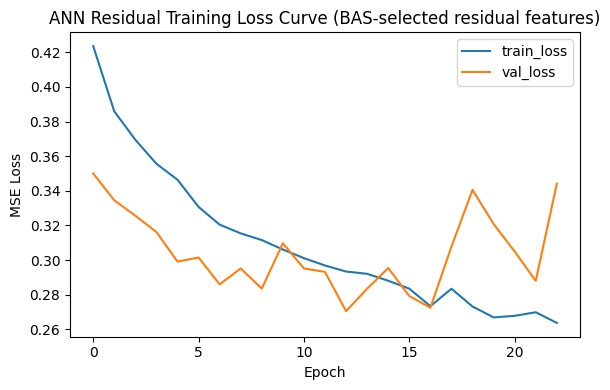

In [12]:
# ---------- ANN on residuals ----------
scaler_res_ann = StandardScaler()
X_train_res_ann = scaler_res_ann.fit_transform(X_train_res)
X_test_res_ann  = scaler_res_ann.transform(X_test_res)

ann_res = build_ann(X_train_res_ann.shape[1])
es_res = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history_res = ann_res.fit(
    X_train_res_ann, res_train,
    validation_split=0.15,
    epochs=200,
    batch_size=256,
    callbacks=[es_res],
    verbose=1
)

res_pred_ann_test = ann_res.predict(X_test_res_ann).ravel()
r2_ann_test, _ = print_metrics("ANN (residual, test)", res_test, res_pred_ann_test)
res_models_test_r2["ANN"] = r2_ann_test
res_models_test_pred["ANN"] = res_pred_ann_test

ann_res_cv_mean, ann_res_cv_std = ann_res_cv_r2(X_train_res, res_train, cv=cv_st)
print(f"ANN residual CV R2 (spatio-temporal, BAS residual features): {ann_res_cv_mean:.4f} ± {ann_res_cv_std:.4f}")
res_models_cv["ANN"] = ann_res_cv_mean

# ---------- Plot ANN residual loss curve ----------
plt.figure(figsize=(6, 4))
plt.plot(history_res.history['loss'], label='train_loss')
plt.plot(history_res.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('ANN Residual Training Loss Curve (BAS-selected residual features)')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# ======================================================
# 8) Combined predictions: chl_hat_total = chl_hat_kd + res_hat (Test set)
# ======================================================
print("\n==================== Stage 3: Combined predictions (Test set) ====================\n")

combined_test_r2 = {}

for name, res_pred_test in res_models_test_pred.items():
    chl_hat_total_test = y_test_base + res_pred_test
    r2, rmse = print_metrics(f"{name} (combined total chl, test)", y_test, chl_hat_total_test)
    combined_test_r2[name] = r2


==================== Stage 3: Combined predictions (Test set) ====================

GAM (combined total chl, test) | R2 = 0.9443 | RMSE = 0.9242
RandomForest (combined total chl, test) | R2 = 0.9542 | RMSE = 0.8377
XGBoost (combined total chl, test) | R2 = 0.9547 | RMSE = 0.8336
Huber (combined total chl, test) | R2 = 0.9343 | RMSE = 1.0033
ANN (combined total chl, test) | R2 = 0.9500 | RMSE = 0.8753


In [14]:
# ======================================================
# 8b) Combined CV R2 for total chl (base + residual)
# ======================================================
print("\n==================== Stage 3b: Combined CV R2 (total chl) ====================\n")

combined_cv_r2 = {}

Xb = X_train_base          # kd-only features
Xr = X_train_res           # BAS-selected residual features
y  = y_train


==================== Stage 3b: Combined CV R2 (total chl) ====================



In [15]:
# ---------- GAM (combined) ----------
scores = []
for tr_idx, val_idx in cv_st.split(Xb):
    # base kd-only model
    xgb_b = xgb_builder_base()
    xgb_b.fit(Xb[tr_idx], y[tr_idx])
    y_base_tr  = xgb_b.predict(Xb[tr_idx])
    y_base_val = xgb_b.predict(Xb[val_idx])

    # residuals on train
    res_tr = y[tr_idx] - y_base_tr

    # residual model
    gam_cv = LinearGAM(terms_res).fit(Xr[tr_idx], res_tr)
    res_val_pred = gam_cv.predict(Xr[val_idx])

    # combined prediction
    y_val_pred = y_base_val + res_val_pred
    scores.append(r2_score(y[val_idx], y_val_pred))

combined_cv_r2["GAM"] = np.mean(scores)

In [16]:
# ---------- Random Forest (combined) ----------
scores = []
for tr_idx, val_idx in cv_st.split(Xb):
    xgb_b = xgb_builder_base()
    xgb_b.fit(Xb[tr_idx], y[tr_idx])
    y_base_tr  = xgb_b.predict(Xb[tr_idx])
    y_base_val = xgb_b.predict(Xb[val_idx])

    res_tr = y[tr_idx] - y_base_tr

    rf_cv = RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf_cv.fit(Xr[tr_idx], res_tr)
    res_val_pred = rf_cv.predict(Xr[val_idx])

    y_val_pred = y_base_val + res_val_pred
    scores.append(r2_score(y[val_idx], y_val_pred))

combined_cv_r2["RandomForest"] = np.mean(scores)


In [17]:
# ---------- XGBoost (combined) ----------
scores = []
for tr_idx, val_idx in cv_st.split(Xb):
    xgb_b = xgb_builder_base()
    xgb_b.fit(Xb[tr_idx], y[tr_idx])
    y_base_tr  = xgb_b.predict(Xb[tr_idx])
    y_base_val = xgb_b.predict(Xb[val_idx])

    res_tr = y[tr_idx] - y_base_tr

    xgb_res_cv = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    xgb_res_cv.fit(Xr[tr_idx], res_tr)
    res_val_pred = xgb_res_cv.predict(Xr[val_idx])

    y_val_pred = y_base_val + res_val_pred
    scores.append(r2_score(y[val_idx], y_val_pred))

combined_cv_r2["XGBoost"] = np.mean(scores)

In [18]:
# ---------- Huber (combined) ----------
scores = []
for tr_idx, val_idx in cv_st.split(Xb):
    xgb_b = xgb_builder_base()
    xgb_b.fit(Xb[tr_idx], y[tr_idx])
    y_base_tr  = xgb_b.predict(Xb[tr_idx])
    y_base_val = xgb_b.predict(Xb[val_idx])

    res_tr = y[tr_idx] - y_base_tr

    sc = StandardScaler()
    Xr_tr_s = sc.fit_transform(Xr[tr_idx])
    Xr_val_s = sc.transform(Xr[val_idx])

    huber_cv = HuberRegressor(epsilon=1.35, max_iter=1000)
    huber_cv.fit(Xr_tr_s, res_tr)
    res_val_pred = huber_cv.predict(Xr_val_s)

    y_val_pred = y_base_val + res_val_pred
    scores.append(r2_score(y[val_idx], y_val_pred))

combined_cv_r2["Huber"] = np.mean(scores)


In [19]:
# ---------- ANN (combined) ----------
scores = []
for tr_idx, val_idx in cv_st.split(Xb):
    xgb_b = xgb_builder_base()
    xgb_b.fit(Xb[tr_idx], y[tr_idx])
    y_base_tr  = xgb_b.predict(Xb[tr_idx])
    y_base_val = xgb_b.predict(Xb[val_idx])

    res_tr = y[tr_idx] - y_base_tr

    sc = StandardScaler()
    Xr_tr_s = sc.fit_transform(Xr[tr_idx])
    Xr_val_s = sc.transform(Xr[val_idx])

    ann_cv = build_ann(Xr_tr_s.shape[1])
    es_cv = EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=0
    )

    ann_cv.fit(
        Xr_tr_s, res_tr,
        epochs=100,
        batch_size=256,
        validation_split=0.1,
        callbacks=[es_cv],
        verbose=0
    )

    res_val_pred = ann_cv.predict(Xr_val_s).ravel()
    y_val_pred = y_base_val + res_val_pred
    scores.append(r2_score(y[val_idx], y_val_pred))

combined_cv_r2["ANN"] = np.mean(scores)

195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [20]:
# ======================================================
# 9) Summary tables
# ======================================================
print("\n=== Summary: KD-only base model ===")
base_test_r2 = r2_score(y_test, y_test_base)
print(f"XGB base (kd only) | CV R2 = {xgb_base_cv_mean:.4f} | Test R2 = {base_test_r2:.4f}")

print("\n=== Summary: Residual models (Test R2 on residuals, BAS-selected features) ===")
for name, r2_val in res_models_test_r2.items():
    print(f"{name:12s} | Residual Test R2 = {r2_val:.4f}")

print("\n=== Summary: Residual models (CV R2 on residuals, BAS-selected features) ===")
for name, cv_r2 in res_models_cv.items():
    print(f"{name:12s} | Residual CV R2 = {cv_r2:.4f}")

print("\n=== Summary: Combined models (total chl, BAS-selected residual features) ===")
for name in res_models_test_pred.keys():
    print(f"{name:12s} | Combined Test R2 = {combined_test_r2[name]:.4f} | Combined CV R2 = {combined_cv_r2[name]:.4f}")



=== Summary: KD-only base model ===
XGB base (kd only) | CV R2 = 0.9380 | Test R2 = 0.9343

=== Summary: Residual models (Test R2 on residuals, BAS-selected features) ===
GAM          | Residual Test R2 = 0.1516
RandomForest | Residual Test R2 = 0.3029
XGBoost      | Residual Test R2 = 0.3097
Huber        | Residual Test R2 = 0.0001
ANN          | Residual Test R2 = 0.2389

=== Summary: Residual models (CV R2 on residuals, BAS-selected features) ===
GAM          | Residual CV R2 = -24.5806
RandomForest | Residual CV R2 = -0.3455
XGBoost      | Residual CV R2 = -0.8147
Huber        | Residual CV R2 = -0.0157
ANN          | Residual CV R2 = -0.6310

=== Summary: Combined models (total chl, BAS-selected residual features) ===
GAM          | Combined Test R2 = 0.9443 | Combined CV R2 = 0.8772
RandomForest | Combined Test R2 = 0.9542 | Combined CV R2 = 0.9401
XGBoost      | Combined Test R2 = 0.9547 | Combined CV R2 = 0.9287
Huber        | Combined Test R2 = 0.9343 | Combined CV R2 = 0.938

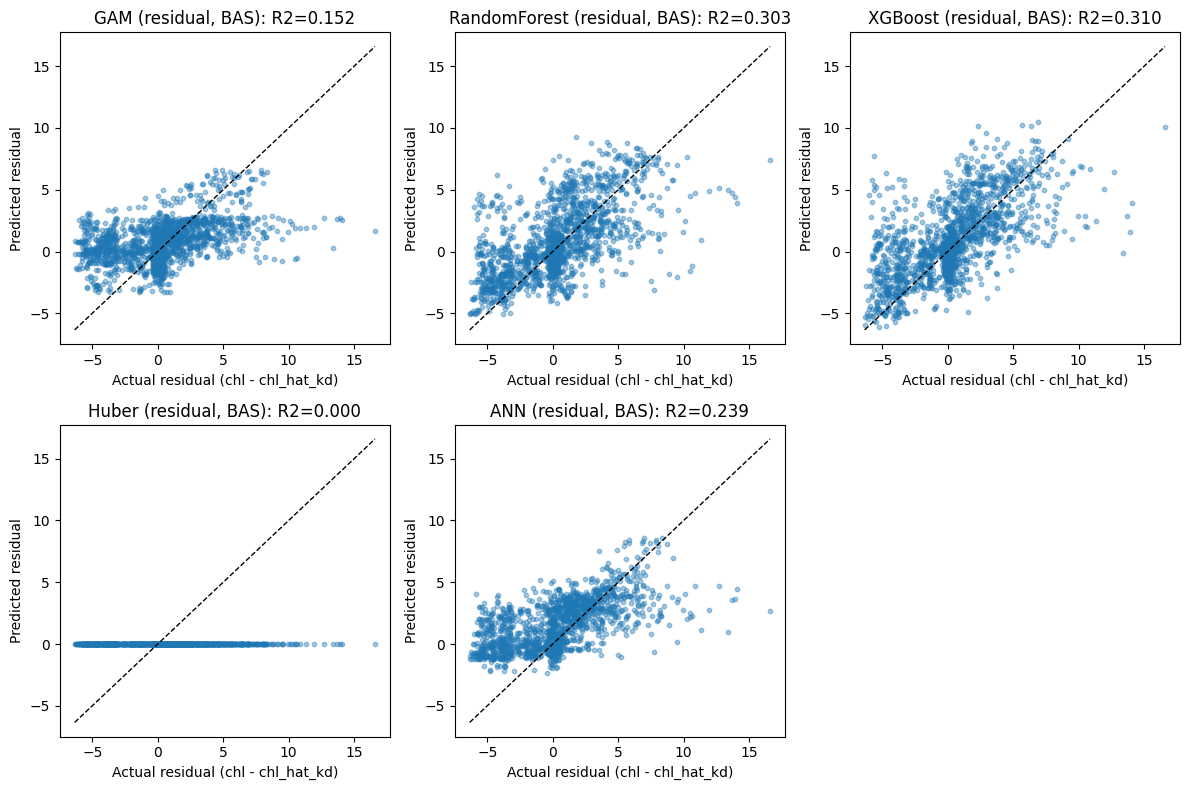

In [21]:
# ======================================================
# 10) Predicted vs Actual plots (residual models only, BAS-selected residual features)
# ======================================================
plt.figure(figsize=(12, 8))

model_preds = {name: res_pred for name, res_pred in res_models_test_pred.items()}
n_models = len(model_preds)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

i = 1
for name, preds in model_preds.items():
    plt.subplot(n_rows, n_cols, i)
    plt.scatter(res_test, preds, s=10, alpha=0.4)
    mn = min(res_test.min(), preds.min())
    mx = max(res_test.max(), preds.max())
    plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
    plt.xlabel("Actual residual (chl - chl_hat_kd)")
    plt.ylabel("Predicted residual")
    plt.title(f"{name} (residual, BAS): R2={r2_score(res_test, preds):.3f}")
    i += 1

plt.tight_layout()
plt.show()


=== Permutation Importance on Residual Models (test set, BAS-selected residual features) ===

RandomForest Residual Permutation Importance:
    fe: 0.4294 ± 0.0046
 spco2: 0.3397 ± 0.0190
   no3: 0.2553 ± 0.0094
    wo: 0.1631 ± 0.0222
    so: 0.0983 ± 0.0074
    ph: 0.0563 ± 0.0042
    vo: -0.0079 ± 0.0082


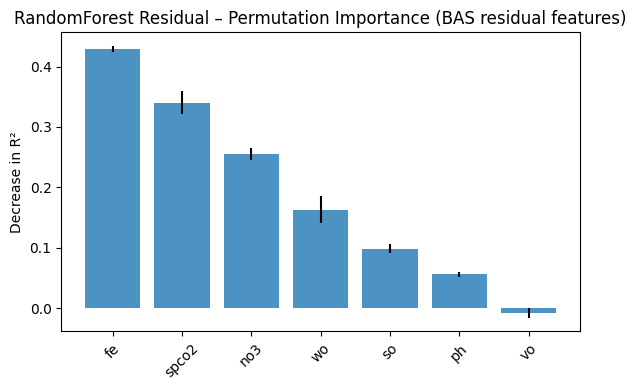


XGBoost Residual Permutation Importance:
 spco2: 0.7363 ± 0.0218
    so: 0.5019 ± 0.0107
   no3: 0.4664 ± 0.0180
    fe: 0.4009 ± 0.0080
    wo: 0.2405 ± 0.0248
    ph: 0.2282 ± 0.0145
    vo: 0.0328 ± 0.0129


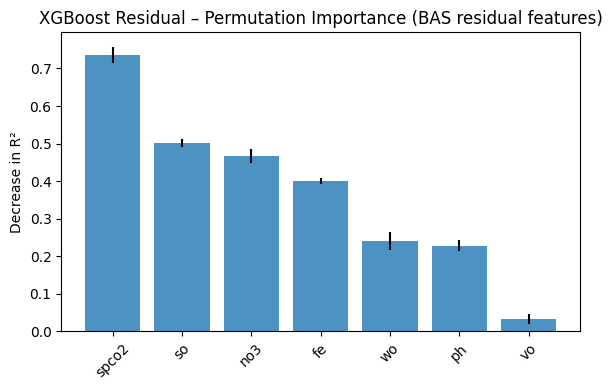


GAM Residual Permutation Importance:
 spco2: 0.2339 ± 0.0059
    fe: 0.1869 ± 0.0026
    so: 0.1067 ± 0.0033
    ph: 0.0931 ± 0.0037
   no3: 0.0606 ± 0.0034
    wo: 0.0027 ± 0.0003
    vo: 0.0001 ± 0.0000


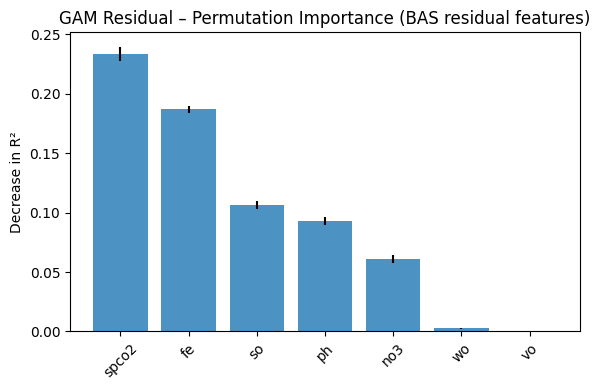

In [22]:
# ======================================================
# 11) Permutation Importance (Residual Models, BAS-selected features)
# ======================================================
print("\n=== Permutation Importance on Residual Models (test set, BAS-selected residual features) ===\n")

# -------------------- Random Forest Residual --------------------
rf_res_pi = permutation_importance(
    rf_res,
    X_test_res,
    res_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("RandomForest Residual Permutation Importance:")
for i in np.argsort(rf_res_pi.importances_mean)[::-1]:
    print(f"{SELECTED_RESIDUAL_FEATURES[i]:>6s}: {rf_res_pi.importances_mean[i]:.4f} ± {rf_res_pi.importances_std[i]:.4f}")

plot_perm_importance(rf_res_pi, SELECTED_RESIDUAL_FEATURES, "RandomForest Residual – Permutation Importance (BAS residual features)")

# -------------------- XGBoost Residual --------------------
xgb_res_pi = permutation_importance(
    xgb_res,
    X_test_res,
    res_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("\nXGBoost Residual Permutation Importance:")
for i in np.argsort(xgb_res_pi.importances_mean)[::-1]:
    print(f"{SELECTED_RESIDUAL_FEATURES[i]:>6s}: {xgb_res_pi.importances_mean[i]:.4f} ± {xgb_res_pi.importances_std[i]:.4f}")

plot_perm_importance(xgb_res_pi, SELECTED_RESIDUAL_FEATURES, "XGBoost Residual – Permutation Importance (BAS residual features)")

# -------------------- GAM Residual --------------------
gam_res_pi = permutation_importance(
    gam_res,
    X_test_res,
    res_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("\nGAM Residual Permutation Importance:")
for i in np.argsort(gam_res_pi.importances_mean)[::-1]:
    print(f"{SELECTED_RESIDUAL_FEATURES[i]:>6s}: {gam_res_pi.importances_mean[i]:.4f} ± {gam_res_pi.importances_std[i]:.4f}")

plot_perm_importance(gam_res_pi, SELECTED_RESIDUAL_FEATURES, "GAM Residual – Permutation Importance (BAS residual features)")


=== SHAP for residual XGBoost (BAS-selected residual features) ===



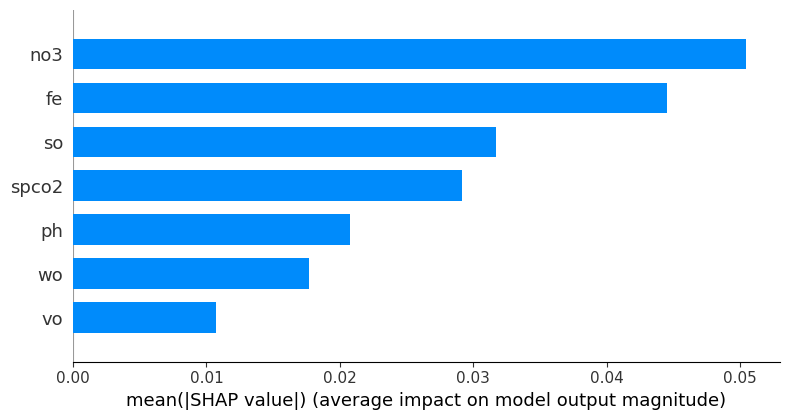

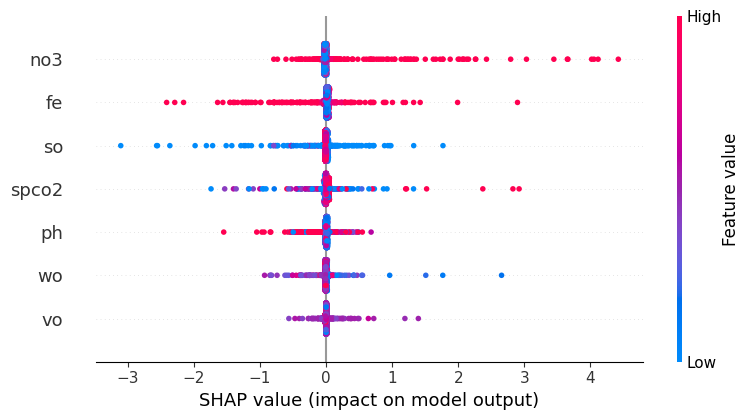

In [23]:
# ======================================================
# 12) SHAP Analysis (for residual XGBoost, BAS-selected residual features)
# ======================================================
print("\n=== SHAP for residual XGBoost (BAS-selected residual features) ===\n")

n_bg = min(3000, X_train_res.shape[0])
rng = np.random.RandomState(RANDOM_STATE)
bg_idx = rng.choice(X_train_res.shape[0], size=n_bg, replace=False)
X_bg_res = X_train_res[bg_idx, :]

explainer_xgb_res = shap.TreeExplainer(xgb_res)
shap_values_xgb_res = explainer_xgb_res.shap_values(X_bg_res)

# Global summary plot (bar)
shap.summary_plot(
    shap_values_xgb_res,
    X_bg_res,
    feature_names=SELECTED_RESIDUAL_FEATURES,
    plot_type="bar",
    show=True
)

# Global summary plot (detailed scatter)
shap.summary_plot(
    shap_values_xgb_res,
    X_bg_res,
    feature_names=SELECTED_RESIDUAL_FEATURES,
    show=True
)